In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q -U mlflow pyngrok xgboost

In [3]:
import mlflow
print("MLflow version:", mlflow.__version__)

MLflow version: 3.15.1


In [4]:
import os
from pathlib import Path

# Use absolute paths so both the Colab client and MLflow server
# always use the same SQLite database and artifact directory.
BASE_DIR = Path("/content")
DB_PATH = BASE_DIR / "mlflow.db"
ARTIFACT_DIR = BASE_DIR / "mlartifacts"

DB_URI = f"sqlite:///{DB_PATH}"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", os.getcwd())
print("MLflow database:", DB_PATH)
print("Artifact directory:", ARTIFACT_DIR)

Working directory: /content
MLflow database: /content/mlflow.db
Artifact directory: /content/mlartifacts


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import time
import os
import json
import warnings
from pathlib import Path
from getpass import getpass

import mlflow
import mlflow.sklearn
from pyngrok import ngrok

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

print("Imports completed.")

Imports completed.


In [6]:
# MLflow configuration
MLFLOW_HOST = "0.0.0.0"
MLFLOW_PORT = 5001
MLFLOW_LOCAL_URL = f"http://127.0.0.1:{MLFLOW_PORT}"
EXPERIMENT_NAME = "employee_attrition"

print("Experiment:", EXPERIMENT_NAME)
print("Local MLflow URL:", MLFLOW_LOCAL_URL)

Experiment: employee_attrition
Local MLflow URL: http://127.0.0.1:5001


In [7]:
# Stop old MLflow/ngrok processes from previous Colab attempts.
# This prevents stale servers/tunnels from causing port and permission conflicts.

os.system("pkill -f 'mlflow server' || true")
os.system("pkill -f 'ngrok' || true")

print("Old MLflow/ngrok processes cleared.")

Old MLflow/ngrok processes cleared.


In [9]:
# Start MLflow 3 tracking server.
#
# The CORS and allowed-host settings are required when the MLflow UI
# is accessed through an ngrok public URL from a browser.

log_file = open("/tmp/mlflow.log", "w")

mlflow_process = subprocess.Popen(
    [
        "mlflow",
        "server",
        "--backend-store-uri", DB_URI,
        "--default-artifact-root", str(ARTIFACT_DIR),
        "--serve-artifacts",
        "--host", MLFLOW_HOST,
        "--port", str(MLFLOW_PORT),
        "--allowed-hosts", "*",
        "--cors-allowed-origins", "*"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT,
)

# Wait for the server to become available.
import urllib.request

server_ready = False
for _ in range(30):
    time.sleep(1)
    try:
        with urllib.request.urlopen(f"{MLFLOW_LOCAL_URL}/health", timeout=2) as response:
            if response.status == 200:
                server_ready = True
                break
    except Exception:
        pass

print("MLflow process running:", mlflow_process.poll() is None)
print("MLflow server ready:", server_ready)

if not server_ready:
    print("\nMLflow server log:")
    print(Path("/tmp/mlflow.log").read_text(errors="ignore"))
    raise RuntimeError(
        "MLflow server did not become ready. "
        "Check /tmp/mlflow.log before continuing."
    )

MLflow process running: True
MLflow server ready: True


In [10]:
print(Path("/tmp/mlflow.log").read_text(errors="ignore"))

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [11]:
# Local health check
!curl -s http://127.0.0.1:5001/health

OK

In [12]:
# Create a fresh ngrok tunnel for the current Colab runtime.
#
# IMPORTANT:
# The previous ngrok error (ERR_NGROK_334) means the reserved/static endpoint
# was already online in another ngrok session. We therefore deliberately use
# a CLEAN ngrok config with NO endpoint/tunnel definition. This forces ngrok
# to create a new temporary public URL instead of reusing the old
# "erratic-graceless-regalia.ngrok-free.dev" endpoint.

from pyngrok import ngrok, conf
from getpass import getpass
import os
import time

# Stop only the local ngrok agent/process from this Colab runtime.
try:
    ngrok.kill()
except Exception:
    pass

os.system("pkill -f ngrok >/dev/null 2>&1 || true")
time.sleep(2)

# Use a completely separate config file so an old "pyngrok-default"
# endpoint/domain cannot be picked up from the persistent Colab config.
CLEAN_NGROK_CONFIG = "/tmp/mlflow_colab_ngrok.yml"
try:
    os.remove(CLEAN_NGROK_CONFIG)
except FileNotFoundError:
    pass

# Ask for the token only if it is not already available as an environment variable.
NGROK_AUTH_TOKEN = os.environ.get("NGROK_AUTHTOKEN")

if not NGROK_AUTH_TOKEN:
    print("Enter your ngrok Auth Token securely (input will not be displayed):")
    NGROK_AUTH_TOKEN = getpass("ngrok Auth Token: ")

if not NGROK_AUTH_TOKEN:
    raise ValueError("An ngrok Auth Token is required.")

# config_version="2" + a clean config file prevents an existing
# pyngrok-default endpoint from being reused.
pyngrok_config = conf.PyngrokConfig(
    config_path=CLEAN_NGROK_CONFIG,
    auth_token=NGROK_AUTH_TOKEN,
    config_version="2",
    startup_timeout=30
)

# Create a NEW temporary public endpoint. Do NOT specify the old domain.
try:
    tunnel = ngrok.connect(
        addr=str(MLFLOW_PORT),
        proto="http",
        pyngrok_config=pyngrok_config
    )
except Exception as e:
    print("First ngrok connection attempt failed.")
    print("Checking for a stale local ngrok process and retrying once...")

    try:
        ngrok.kill()
    except Exception:
        pass

    os.system("pkill -f ngrok >/dev/null 2>&1 || true")
    time.sleep(3)

    tunnel = ngrok.connect(
        addr=str(MLFLOW_PORT),
        proto="http",
        pyngrok_config=pyngrok_config
    )

MLFLOW_PUBLIC_URL = tunnel.public_url

print("=" * 70)
print("MLflow Dashboard URL:")
print(MLFLOW_PUBLIC_URL)
print("=" * 70)
print(f"Forwarding to: http://127.0.0.1:{MLFLOW_PORT}")
print("Keep this Colab runtime running while using the dashboard.")


Enter your ngrok Auth Token securely (input will not be displayed):
ngrok Auth Token: ··········
MLflow Dashboard URL:
https://erratic-graceless-regalia.ngrok-free.dev
Forwarding to: http://127.0.0.1:5001
Keep this Colab runtime running while using the dashboard.


In [13]:
# IMPORTANT:
# All Python MLflow operations use the tracking SERVER.
# Do not switch back to sqlite:///mlflow.db in later cells.

mlflow.set_tracking_uri(MLFLOW_LOCAL_URL)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", EXPERIMENT_NAME)

Tracking URI: http://127.0.0.1:5001
Experiment: employee_attrition


In [ ]:
# ngrok security note
#
# The notebook does not store the ngrok Auth Token in source code.
# A clean temporary config is used for this Colab runtime so that a
# previously configured/reserved endpoint cannot be reused accidentally.
#
# The dashboard URL is printed by the ngrok cell above.


In [14]:
df = pd.read_csv("/content/drive/MyDrive/data_employee_attrition.csv")

In [15]:
df.head() # target feature is Attrition it has values Yes or No so it is classification problem

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [16]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [17]:
df.shape    # rows=1470, columns=35

(1470, 35)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [19]:
num_colmns = df.select_dtypes(include=['number'])
cat_colmns = df.select_dtypes(include=['object'])

In [20]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


'''
By observing the mean and 50% the feature 'DistanceFromHome' is right skwed and 'EmployeeNumber' is also little right skwed.
The 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion' and 'YearsWithCurrManager' its 75% amd max values comparionsion is very high, it may containe outliers.

'''

In [21]:
df.describe(include="object")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


#The featute Over18 has only 1 unique value so it will not contribute any thing for prediction, we can drop this feature

In [22]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [23]:
df.isnull().sum()   #There is no missing values present in the dateset

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [24]:
duplicates = df.duplicated().sum()  #There are no duplicates present in the dataset
print(duplicates)

0


In [25]:
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


# 'StandardHours ,'Over18' and  'EmployeeCount' has only 1 unique vale it will not contribute for prediction so we can drop these 3 features

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


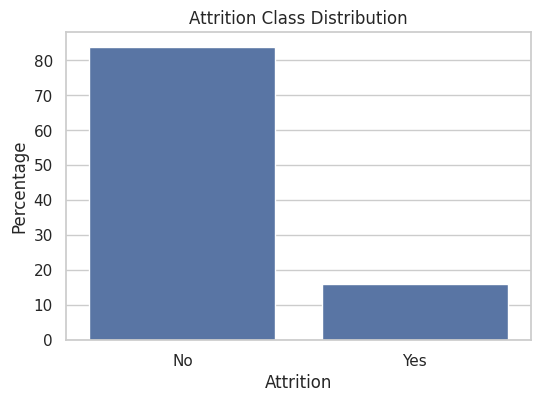

In [26]:
attrition_percent = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(attrition_percent)

plt.figure(figsize=(6, 4))
sns.barplot(x=attrition_percent.index, y=attrition_percent.values)
plt.title("Attrition Class Distribution")
plt.xlabel("Attrition")
plt.ylabel("Percentage")
plt.show()

# #Target feature has an imbalanced data

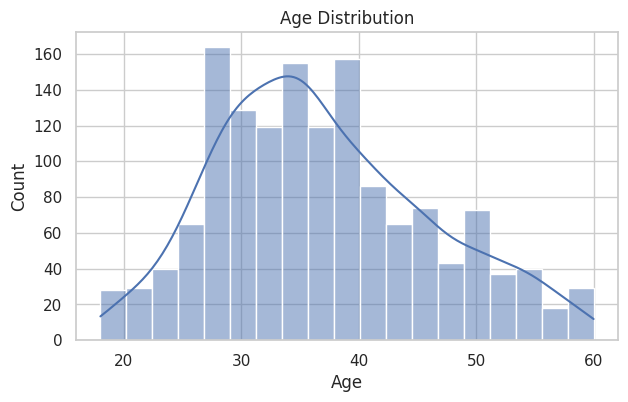

In [27]:
plt.figure(figsize=(7, 4))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='Department'>

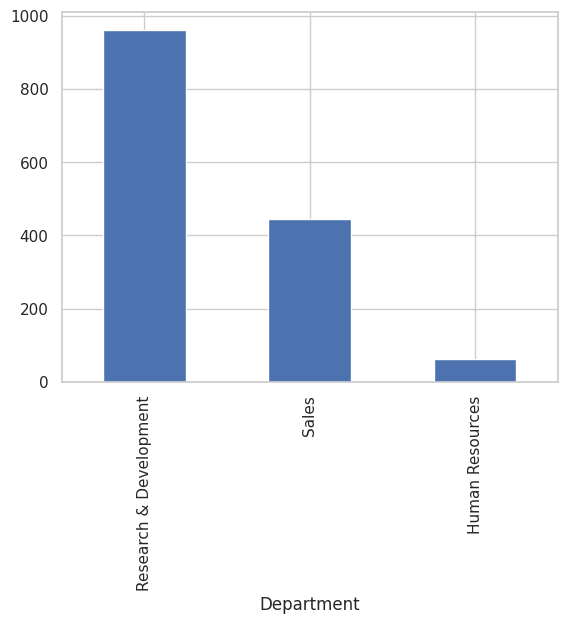

In [28]:
df["Department"].value_counts().plot(kind="bar")

In [29]:
df.corr(numeric_only=True)   # bivariate analysis Numerical vs Numerical

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


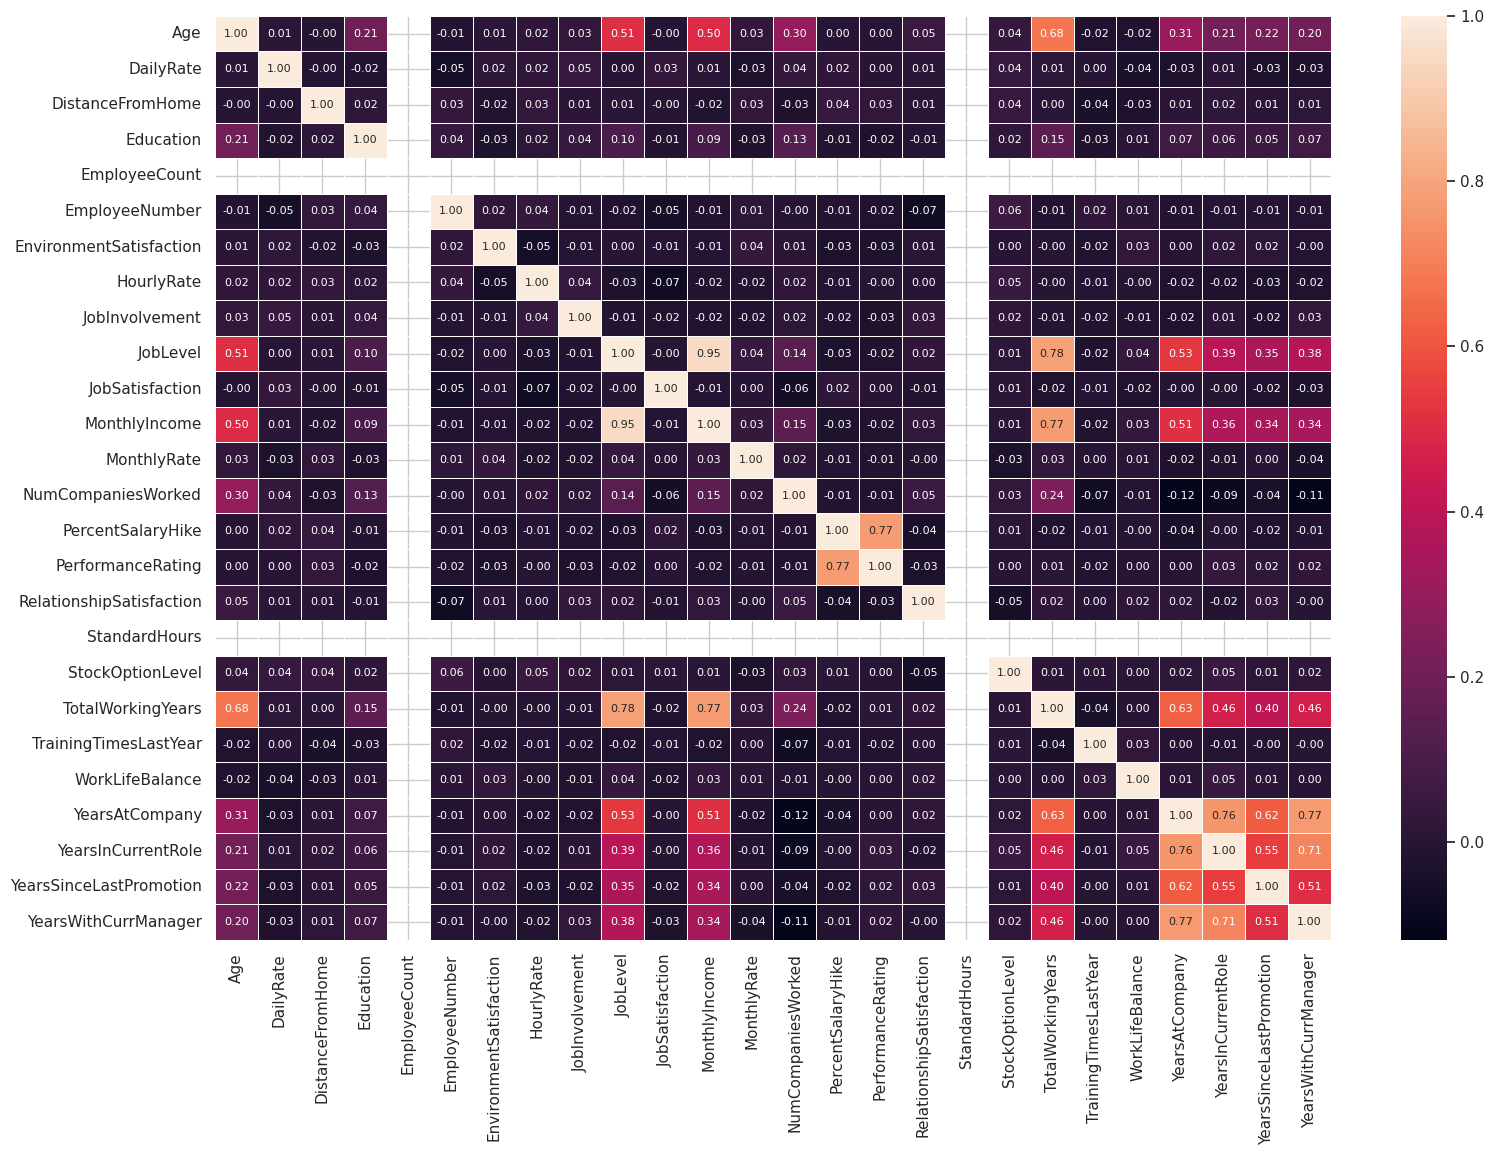

In [30]:
plt.figure(figsize=(18,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size":8})
plt.show()

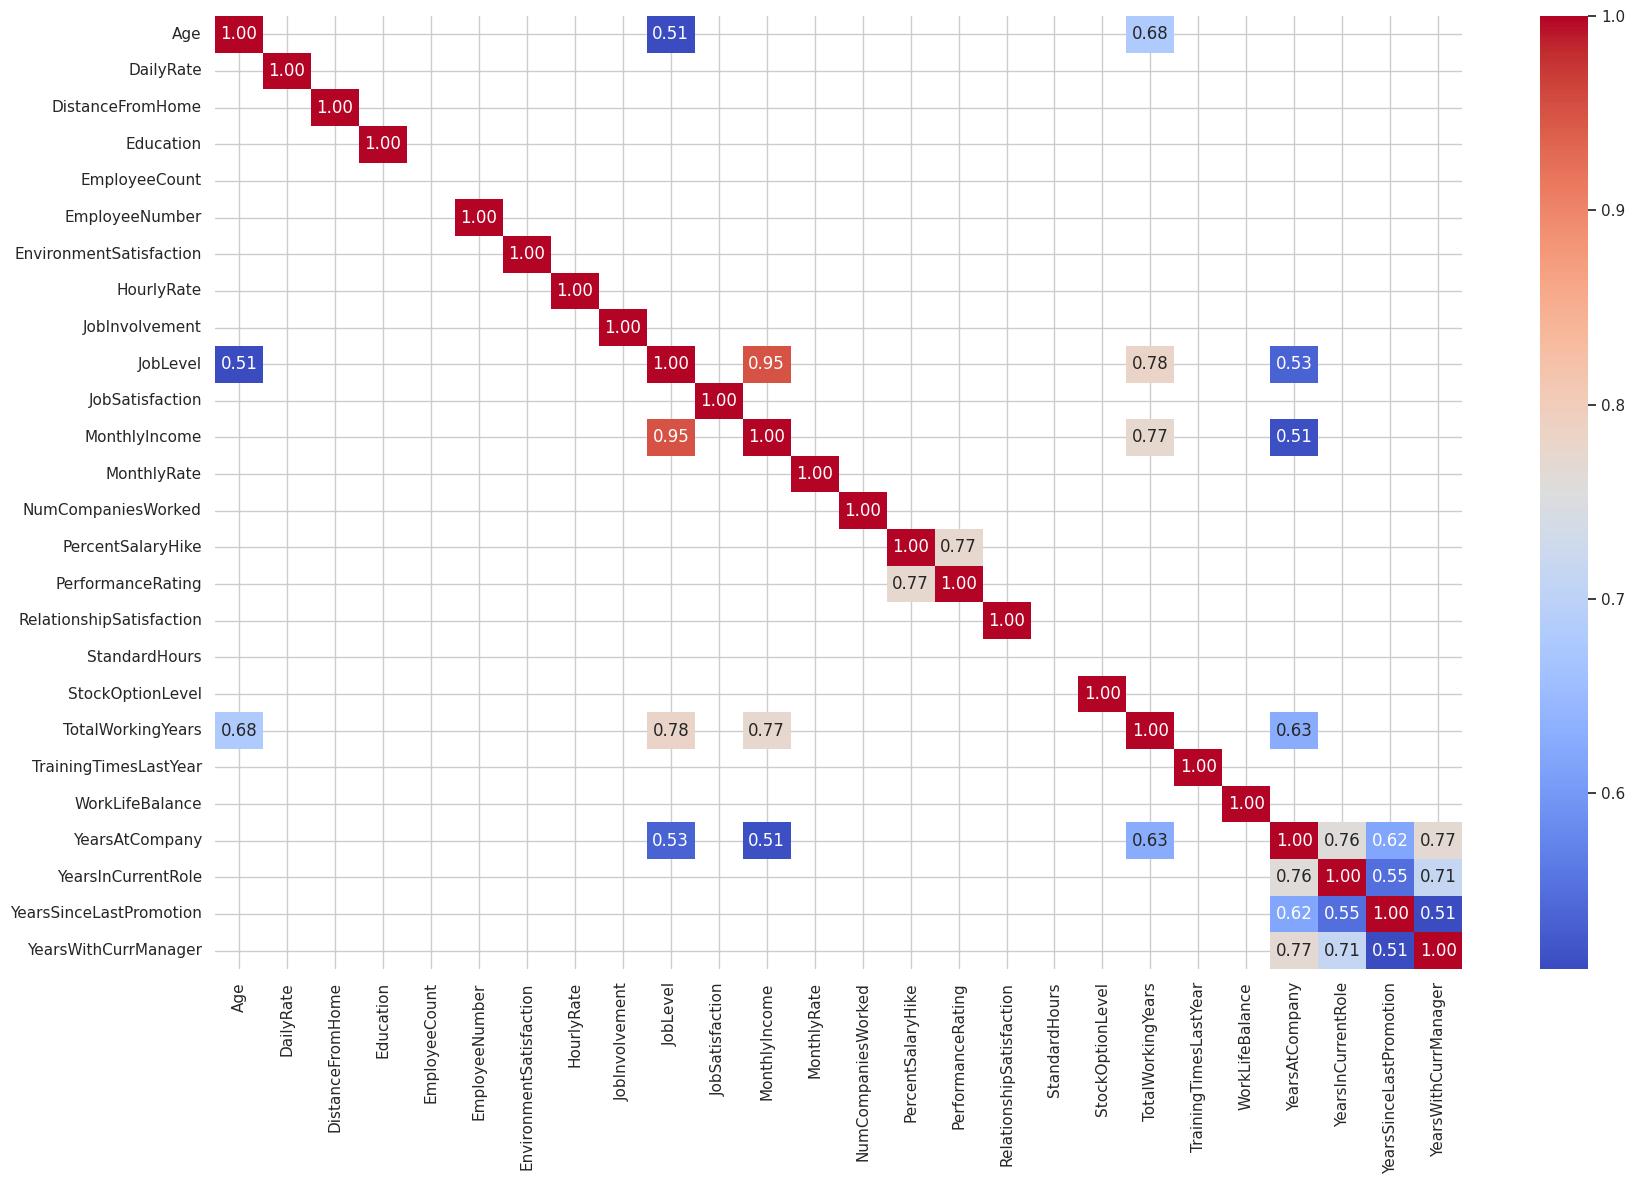

In [31]:
# highly correlated features
corr = df.corr(numeric_only=True)

plt.figure(figsize=(18, 12))
sns.heatmap(
    corr[(corr.abs() > 0.5)],
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.tight_layout()
plt.show()

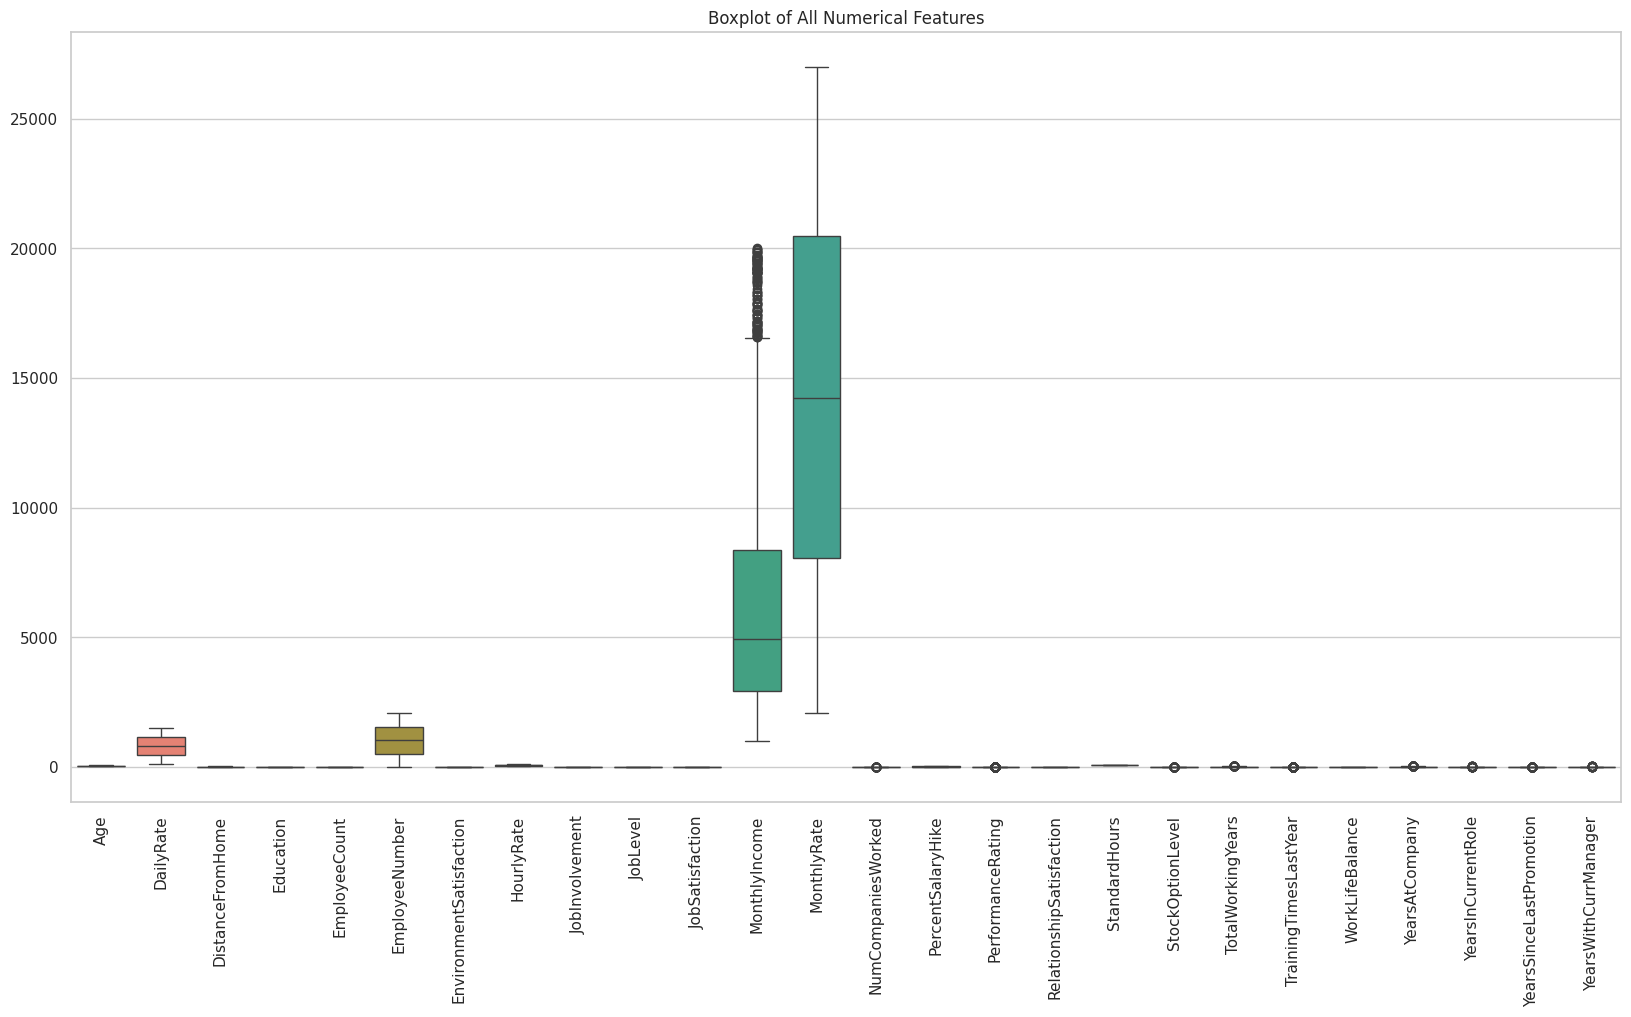

In [32]:
num_colmns = df.select_dtypes(include='number').columns
plt.figure(figsize=(20, 10))
sns.boxplot(data=df[num_colmns])

plt.xticks(rotation=90)
plt.title("Boxplot of All Numerical Features")
plt.show()

As per above boxplot observation MonthlyIncome feature has outliers

In [33]:
outlier_summary = []

for col in num_colmns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Outlier Count": count,
        "Outlier %": round((count / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values("Outlier Count", ascending=False)

,Column,Outlier Count,Outlier %
20,TrainingTimesLastYear,238,16.19
15,PerformanceRating,226,15.37
11,MonthlyIncome,114,7.76
24,YearsSinceLastPromotion,107,7.28
22,YearsAtCompany,104,7.07
18,StockOptionLevel,85,5.78
19,TotalWorkingYears,63,4.29
13,NumCompaniesWorked,52,3.54
23,YearsInCurrentRole,21,1.43
25,YearsWithCurrManager,14,0.95


In [34]:
df.skew(numeric_only=True) # To check skew in the data

,0
Age,0.413286
DailyRate,-0.003519
DistanceFromHome,0.958118
Education,-0.289681
EmployeeCount,0.000000
EmployeeNumber,0.016574
EnvironmentSatisfaction,-0.321654
HourlyRate,-0.032311
JobInvolvement,-0.498419
JobLevel,1.025401


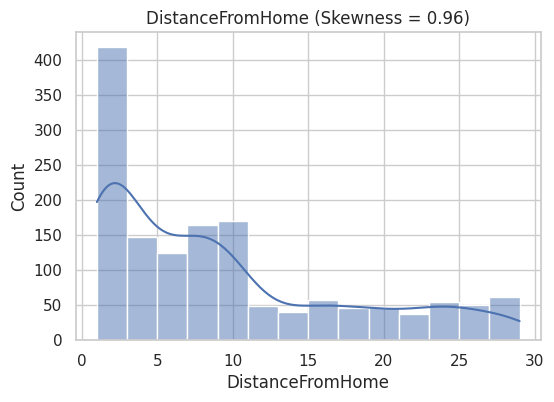

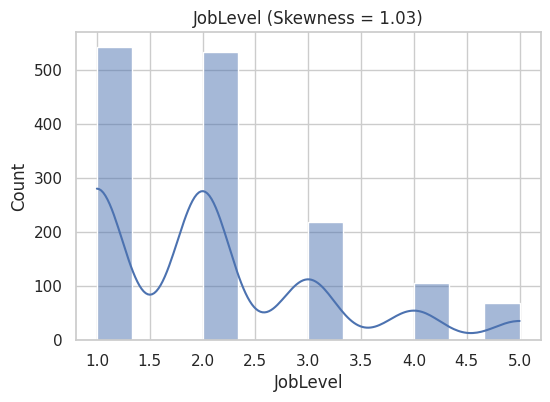

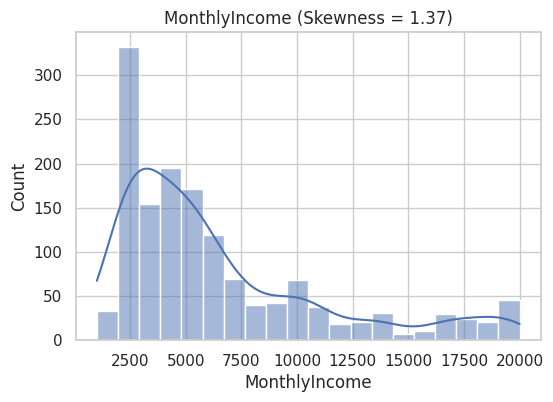

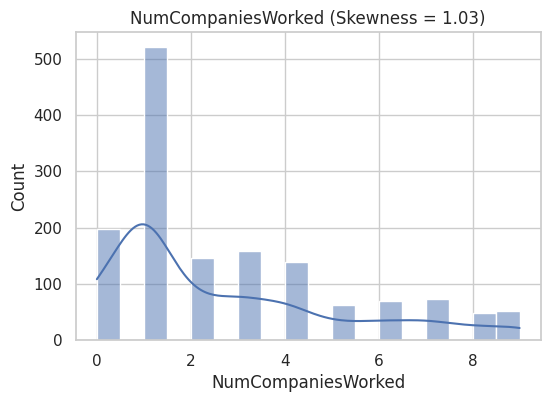

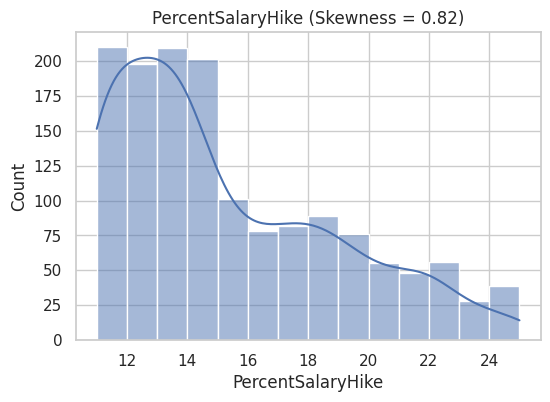

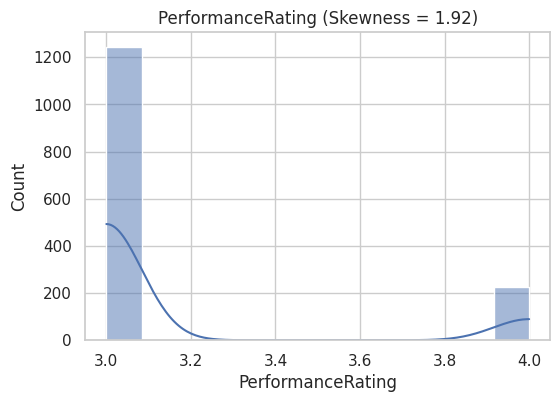

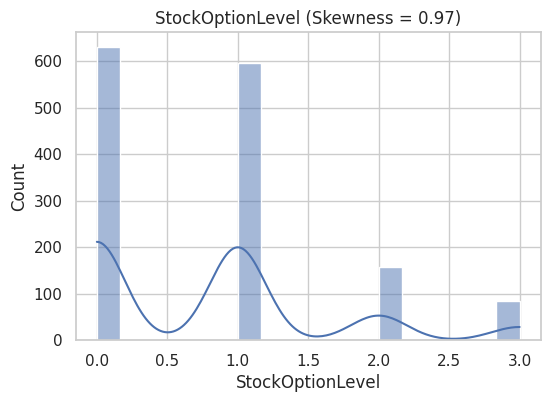

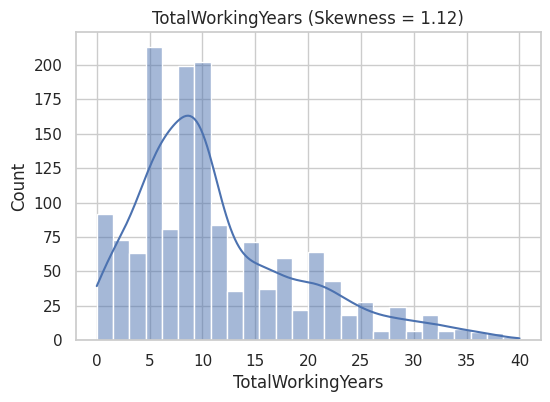

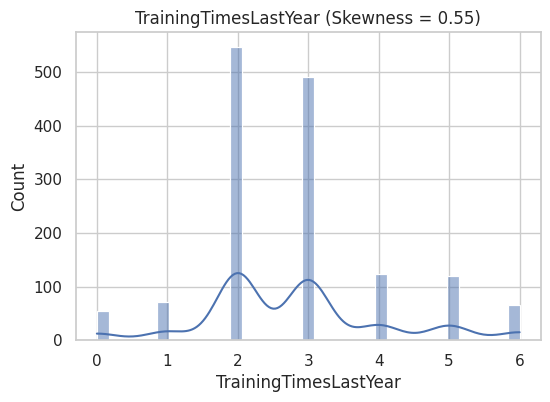

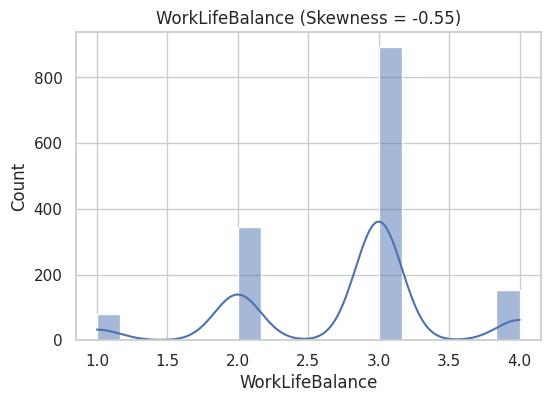

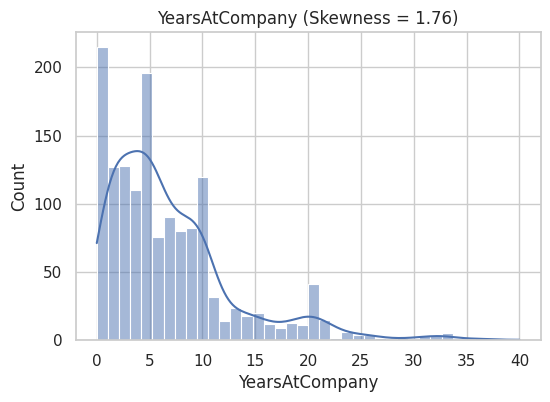

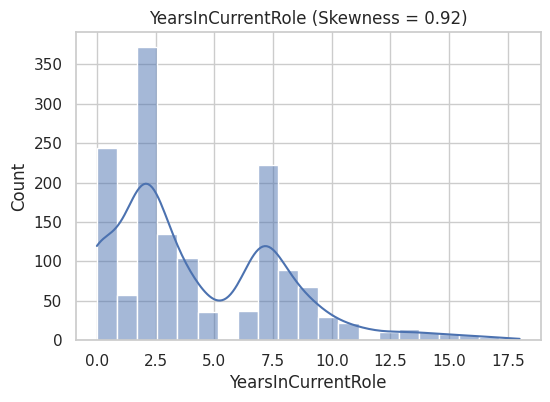

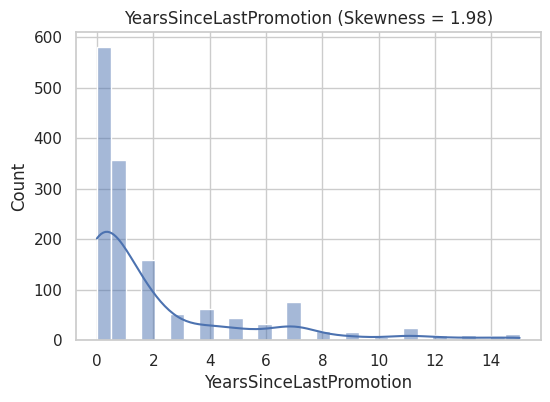

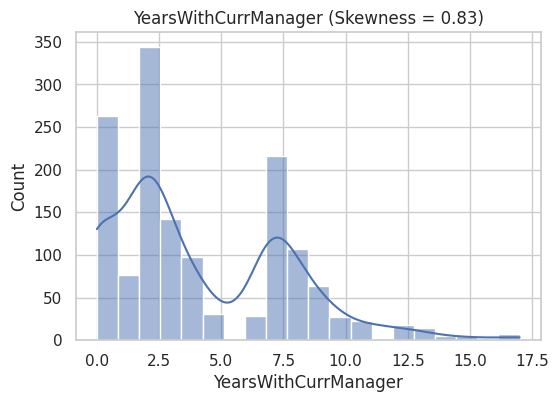

In [35]:
skewness = df.skew(numeric_only=True)

for col in skewness[abs(skewness) > 0.5].index:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} (Skewness = {skewness[col]:.2f})")
    plt.show()

In [36]:
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1}) # converting Attrition feature into numarical

##Observation
1.Dataset contains 1470 rows and 35 columns.

2.Outliers are present in these features TrainingTimesLastYear,PerformanceRating, MonthlyIncome, YearsSinceLastPromotion, YearsAtCompany, StockOptionLevel, TotalWorkingYears,NumCompaniesWorked, YearsInCurrentRole and YearsWithCurrManager

3.Target feature has an imbalanced data (83.87% and 16.13%)

4.'StandardHours ,'Over18' and  'EmployeeCount' has only 1 unique value it will not contribute for prediction so we can drop these 3 features

5.By observing the mean and 50% the feature 'DistanceFromHome' is right skwed and 'EmployeeNumber' is also little right skwed.
The 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion' and 'YearsWithCurrManager' its 75% amd max values comparionsion is very high, it may containe outliers.

6.DistanceFromHome,MonthlyIncome, NumCompaniesWorked, PerformanceRating, TotalWorkingYears, YearsAtCompany, YearsSinceLastPromotion and YearsWithCurrManager are highly right skewd



###Feature Engineering

In [37]:
df.drop(columns=['EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)

In [38]:
df.shape

(1470, 32)

In [39]:
# Columns to check for outliers
columns = ["TrainingTimesLastYear","PerformanceRating", "MonthlyIncome", "YearsSinceLastPromotion", "YearsAtCompany", "StockOptionLevel", "TotalWorkingYears","NumCompaniesWorked", "YearsInCurrentRole", "YearsWithCurrManager"]

# Create a copy of the dataframe
df_clean = df.copy()

for col in columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remove outliers
    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

print("Original Shape:", df.shape)
print("Shape After Removing Outliers:", df_clean.shape)

Original Shape: (1470, 32)
Shape After Removing Outliers: (644, 32)


In [40]:
# Handling the skewed numerical features using Yeo-Johnson transformation.
from sklearn.preprocessing import PowerTransformer

cols = [
    "DistanceFromHome",
    "MonthlyIncome",
    "JobLevel",
    "PerformanceRating",
    "NumCompaniesWorked",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

pt = PowerTransformer(method="yeo-johnson")
df[cols] = pt.fit_transform(df[cols])

print("Yeo-Johnson transformation applied to:")
print(cols)

Yeo-Johnson transformation applied to:
['DistanceFromHome', 'MonthlyIncome', 'JobLevel', 'PerformanceRating', 'NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [41]:
df.select_dtypes(include='object').columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [42]:
df['OverTime'].value_counts()

,count
OverTime,
No,1054
Yes,416


In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

#for col in cat_cols:
    #df[col] = le.fit_transform(df[col])

In [44]:
#converting object features into numarical features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['OverTime'] = le.fit_transform(df['OverTime'])

In [45]:
# Converting categorical features into numerical features.
#
# The original notebook attempted to assign the full OneHotEncoder matrix
# back into one dataframe column. That is not valid when a column has more
# than two categories. The corrected implementation preserves the intended
# one-hot encoding with drop_first=True.

from sklearn.preprocessing import OneHotEncoder

cat_cols = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus"
]

encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

encoded_array = encoder.fit_transform(df[cat_cols])

encoded_columns = encoder.get_feature_names_out(cat_cols)

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_columns,
    index=df.index
)

df = pd.concat(
    [
        df.drop(columns=cat_cols),
        encoded_df
    ],
    axis=1
)

print("One-hot encoded columns:")
print(encoded_columns.tolist())
print("New dataframe shape:", df.shape)

One-hot encoded columns:
['BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']
New dataframe shape: (1470, 46)


In [46]:
df.drop(columns=['EmployeeCount'], inplace=True)

In [47]:
df.shape

(1470, 45)

In [48]:
# Feature selection using Mutual Information.
from sklearn.feature_selection import mutual_info_classif

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

mi = mutual_info_classif(
    X,
    y,
    random_state=50
)

mi_scores = (
    pd.Series(mi, index=X.columns)
    .sort_values(ascending=False)
)

print(mi_scores)

StockOptionLevel                     0.034169
MonthlyIncome                        0.033040
TotalWorkingYears                    0.027201
JobLevel                             0.022851
BusinessTravel_Travel_Frequently     0.022146
Age                                  0.021324
YearsSinceLastPromotion              0.020328
TrainingTimesLastYear                0.016949
OverTime                             0.014832
RelationshipSatisfaction             0.013995
YearsAtCompany                       0.013317
JobRole_Sales Representative         0.012144
PercentSalaryHike                    0.012111
JobRole_Research Scientist           0.010704
JobRole_Research Director            0.009881
YearsInCurrentRole                   0.008755
MaritalStatus_Married                0.007511
MaritalStatus_Single                 0.005034
JobRole_Manufacturing Director       0.004818
JobRole_Human Resources              0.004624
NumCompaniesWorked                   0.003488
EnvironmentSatisfaction           

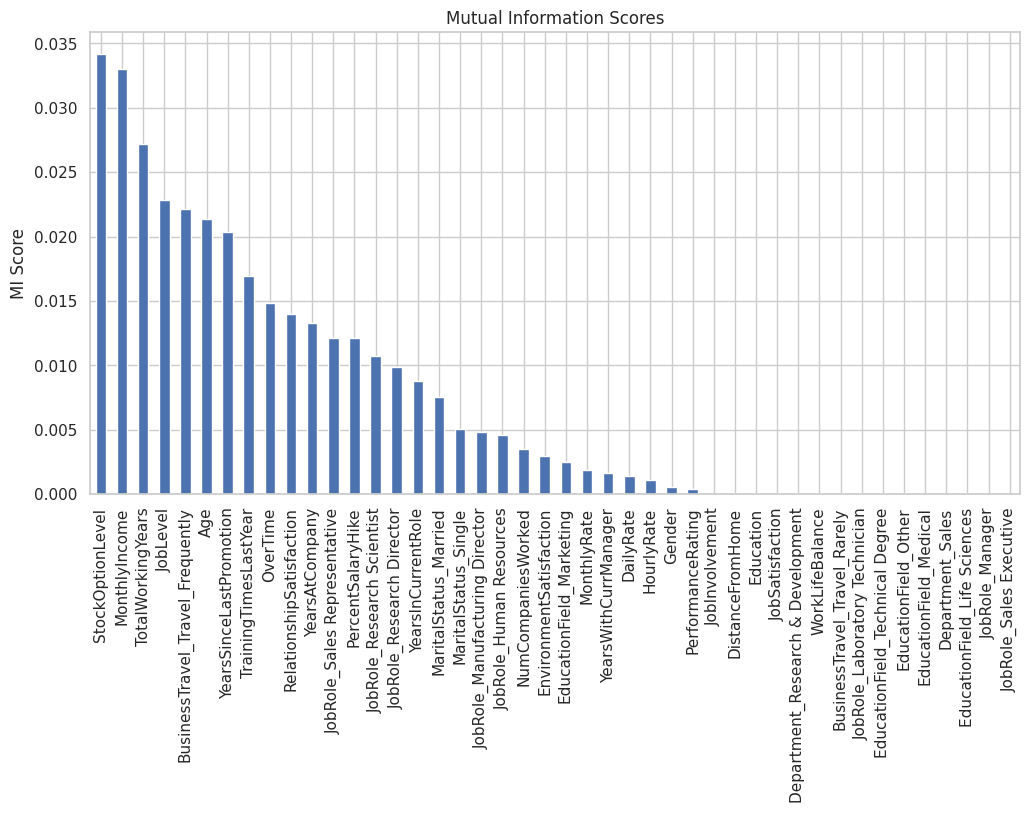

In [49]:
import matplotlib.pyplot as plt

mi_scores.plot(kind="bar", figsize=(12,6))
plt.title("Mutual Information Scores")
plt.ylabel("MI Score")
plt.show()

In [50]:
selected_features = mi_scores[mi_scores > 0].index

X_selected = X[selected_features]

print(selected_features)

Index(['StockOptionLevel', 'MonthlyIncome', 'TotalWorkingYears', 'JobLevel',
       'BusinessTravel_Travel_Frequently', 'Age', 'YearsSinceLastPromotion',
       'TrainingTimesLastYear', 'OverTime', 'RelationshipSatisfaction',
       'YearsAtCompany', 'JobRole_Sales Representative', 'PercentSalaryHike',
       'JobRole_Research Scientist', 'JobRole_Research Director',
       'YearsInCurrentRole', 'MaritalStatus_Married', 'MaritalStatus_Single',
       'JobRole_Manufacturing Director', 'JobRole_Human Resources',
       'NumCompaniesWorked', 'EnvironmentSatisfaction',
       'EducationField_Marketing', 'MonthlyRate', 'YearsWithCurrManager',
       'DailyRate', 'HourlyRate', 'Gender', 'PerformanceRating'],
      dtype='object')


In [51]:
print(X.shape)
print(X_selected.shape)

(1470, 44)
(1470, 29)


#Train Test Split

In [52]:
from sklearn.model_selection import train_test_split

# Final independent test set.
# Validation will be performed later using stratified 5-fold CV on X_train.
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("Testing target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training shape: (1176, 29)
Testing shape : (294, 29)
Training target distribution:
Attrition
0    0.838
1    0.162
Name: proportion, dtype: float64
Testing target distribution:
Attrition
0    0.84
1    0.16
Name: proportion, dtype: float64


#Train a Model

In [53]:
# Validation strategy:
# - Training: X_train / y_train
# - Validation: 5-fold Stratified Cross-Validation on X_train / y_train
# - Final testing: untouched X_test / y_test
#
# We use explicit MLflow logging instead of mlflow.autolog() so that every
# parameter, validation metric, test metric, visualization, and model is
# easy to identify in the MLflow UI.

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
from mlflow.models import infer_signature

CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=50
)

PLOTS_DIR = Path("/content/mlflow_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("5-fold stratified cross-validation configured.")

5-fold stratified cross-validation configured.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Validation Accuracy: 0.8657 ± 0.0127
Validation AUC     : 0.8067 ± 0.0345
Test Accuracy      : 0.8673
Test AUC           : 0.8072

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.70      0.30      0.42        47

    accuracy                           0.87       294
   macro avg       0.79      0.64      0.67       294
weighted avg       0.85      0.87      0.84       294



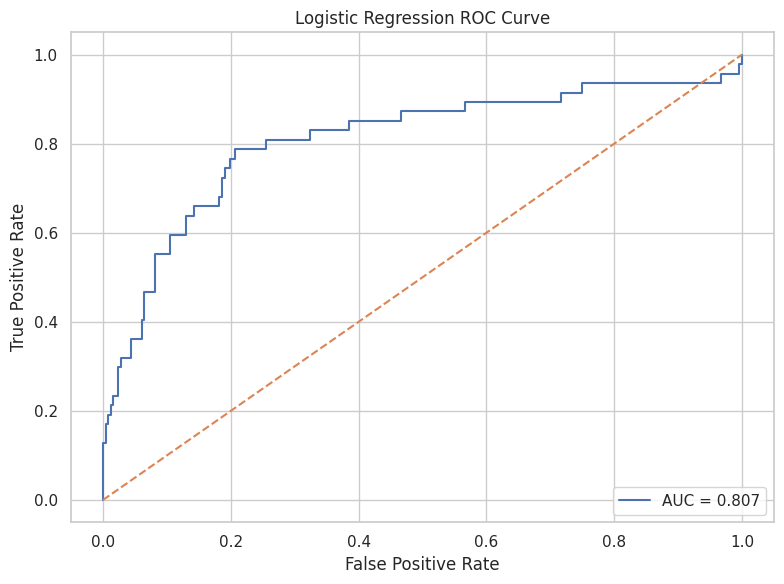

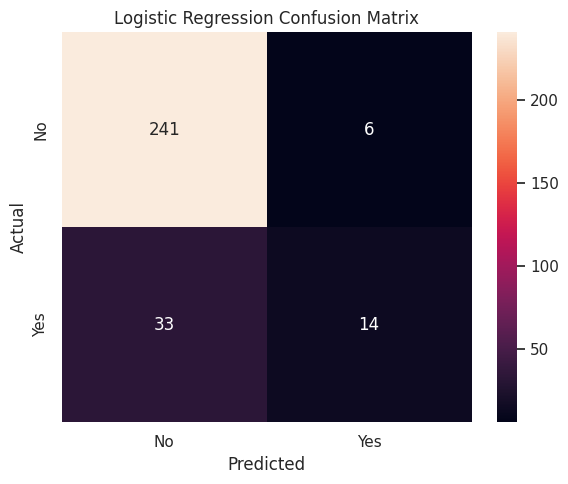

/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Run ID: 4f376a8814814b4887ad38dab2e840c7
Logged Model ID: m-b5c24b22135c499581e18774584fa831
🏃 View run LogisticRegression at: http://127.0.0.1:5001/#/experiments/1/runs/4f376a8814814b4887ad38dab2e840c7
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


In [54]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=10000)

with mlflow.start_run(run_name="LogisticRegression") as run:

    # -------------------------
    # Validation
    # -------------------------
    cv_results = cross_validate(
        log_reg,
        X_train,
        y_train,
        cv=CV,
        scoring=["accuracy", "roc_auc", "precision", "recall", "f1"],
        n_jobs=-1
    )

    val_accuracy_mean = cv_results["test_accuracy"].mean()
    val_accuracy_std = cv_results["test_accuracy"].std()
    val_auc_mean = cv_results["test_roc_auc"].mean()
    val_auc_std = cv_results["test_roc_auc"].std()

    # -------------------------
    # Train final model
    # -------------------------
    log_reg.fit(X_train, y_train)

    y_pred = log_reg.predict(X_test)
    y_prob = log_reg.predict_proba(X_test)[:, 1]

    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, zero_division=0)
    test_recall = recall_score(y_test, y_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_pred, zero_division=0)
    test_auc = roc_auc_score(y_test, y_prob)

    print("Logistic Regression")
    print("Validation Accuracy:", f"{val_accuracy_mean:.4f} ± {val_accuracy_std:.4f}")
    print("Validation AUC     :", f"{val_auc_mean:.4f} ± {val_auc_std:.4f}")
    print("Test Accuracy      :", f"{test_accuracy:.4f}")
    print("Test AUC           :", f"{test_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # -------------------------
    # MLflow parameters/metrics
    # -------------------------
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_iter", 10000)
    mlflow.log_param("validation_folds", 5)

    mlflow.log_metric("validation_accuracy_mean", val_accuracy_mean)
    mlflow.log_metric("validation_accuracy_std", val_accuracy_std)
    mlflow.log_metric("validation_auc_mean", val_auc_mean)
    mlflow.log_metric("validation_auc_std", val_auc_std)

    mlflow.log_metric("accuracy", test_accuracy)
    mlflow.log_metric("precision", test_precision)
    mlflow.log_metric("recall", test_recall)
    mlflow.log_metric("f1_score", test_f1)
    mlflow.log_metric("auc", test_auc)

    # -------------------------
    # ROC visualization
    # -------------------------
    log_fpr, log_tpr, log_thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(
        log_fpr,
        log_tpr,
        label=f"AUC = {test_auc:.3f}"
    )
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Logistic Regression ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()

    log_roc_path = PLOTS_DIR / "logistic_regression_roc.png"
    plt.savefig(log_roc_path, dpi=150, bbox_inches="tight")
    plt.show()
    mlflow.log_artifact(str(log_roc_path), artifact_path="visualizations")

    # -------------------------
    # Confusion matrix
    # -------------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Logistic Regression Confusion Matrix")
    plt.tight_layout()

    log_cm_path = PLOTS_DIR / "logistic_regression_confusion_matrix.png"
    plt.savefig(log_cm_path, dpi=150, bbox_inches="tight")
    plt.show()
    mlflow.log_artifact(str(log_cm_path), artifact_path="visualizations")

    # -------------------------
    # Model signature + input example
    # -------------------------
    signature = infer_signature(
        X_train.head(5),
        log_reg.predict(X_train.head(5))
    )

    model_input_example = X_train.head(5)

    model_info_log = mlflow.sklearn.log_model(
        log_reg,
        name="logistic_regression_model",
        signature=signature,
        input_example=model_input_example
    )

    print("Run ID:", run.info.run_id)
    print("Logged Model ID:", model_info_log.model_id)

Random Forest
Validation Accuracy: 0.8529 ± 0.0084
Validation AUC     : 0.7678 ± 0.0449
Test Accuracy      : 0.8707
Test AUC           : 0.7947

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       247
           1       1.00      0.19      0.32        47

    accuracy                           0.87       294
   macro avg       0.93      0.60      0.62       294
weighted avg       0.89      0.87      0.83       294



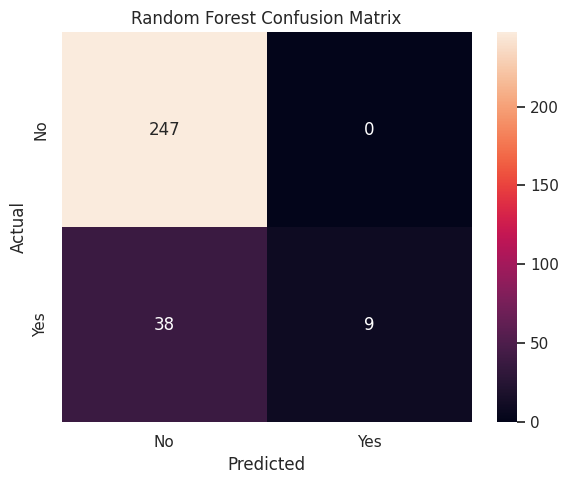

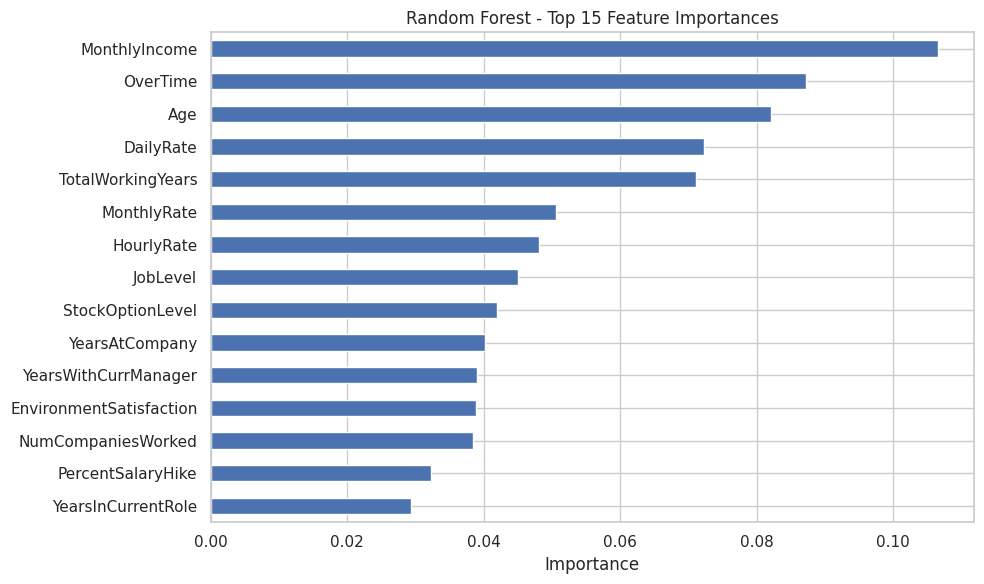

/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Run ID: 354a42c9a9b542098b068cecf24f1ffa
Logged Model ID: m-ada8d82ce58c40b8bcccaa9420934a5d
🏃 View run Random_Forest_Mdl at: http://127.0.0.1:5001/#/experiments/1/runs/354a42c9a9b542098b068cecf24f1ffa
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


In [55]:
# ============================================================
# MODEL 2: RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=50
)

with mlflow.start_run(run_name="Random_Forest_Mdl") as run:

    # -------------------------
    # Validation
    # -------------------------
    cv_results = cross_validate(
        model2,
        X_train,
        y_train,
        cv=CV,
        scoring=["accuracy", "roc_auc", "precision", "recall", "f1"],
        n_jobs=-1
    )

    rf_val_accuracy_mean = cv_results["test_accuracy"].mean()
    rf_val_accuracy_std = cv_results["test_accuracy"].std()
    rf_val_auc_mean = cv_results["test_roc_auc"].mean()
    rf_val_auc_std = cv_results["test_roc_auc"].std()

    # -------------------------
    # Train final model
    # -------------------------
    model2.fit(X_train, y_train)

    y_pred2 = model2.predict(X_test)
    y_prob2 = model2.predict_proba(X_test)[:, 1]

    rf_accuracy = accuracy_score(y_test, y_pred2)
    rf_precision = precision_score(y_test, y_pred2, zero_division=0)
    rf_recall = recall_score(y_test, y_pred2, zero_division=0)
    rf_f1 = f1_score(y_test, y_pred2, zero_division=0)
    rf_auc = roc_auc_score(y_test, y_prob2)

    print("Random Forest")
    print("Validation Accuracy:", f"{rf_val_accuracy_mean:.4f} ± {rf_val_accuracy_std:.4f}")
    print("Validation AUC     :", f"{rf_val_auc_mean:.4f} ± {rf_val_auc_std:.4f}")
    print("Test Accuracy      :", f"{rf_accuracy:.4f}")
    print("Test AUC           :", f"{rf_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred2, zero_division=0))

    # -------------------------
    # MLflow parameters/metrics
    # -------------------------
    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("random_state", 50)
    mlflow.log_param("validation_folds", 5)

    mlflow.log_metric("validation_accuracy_mean", rf_val_accuracy_mean)
    mlflow.log_metric("validation_accuracy_std", rf_val_accuracy_std)
    mlflow.log_metric("validation_auc_mean", rf_val_auc_mean)
    mlflow.log_metric("validation_auc_std", rf_val_auc_std)

    mlflow.log_metric("accuracy", rf_accuracy)
    mlflow.log_metric("precision", rf_precision)
    mlflow.log_metric("recall", rf_recall)
    mlflow.log_metric("f1_score", rf_f1)
    mlflow.log_metric("auc", rf_auc)

    # -------------------------
    # ROC
    # -------------------------
    rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, y_prob2)

    # -------------------------
    # Confusion matrix
    # -------------------------
    rf_cm = confusion_matrix(y_test, y_pred2)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        rf_cm,
        annot=True,
        fmt="d",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Random Forest Confusion Matrix")
    plt.tight_layout()

    rf_cm_path = PLOTS_DIR / "random_forest_confusion_matrix.png"
    plt.savefig(rf_cm_path, dpi=150, bbox_inches="tight")
    plt.show()
    mlflow.log_artifact(str(rf_cm_path), artifact_path="visualizations")

    # -------------------------
    # Feature importance
    # -------------------------
    rf_importance = (
        pd.Series(model2.feature_importances_, index=X_train.columns)
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10, 6))
    rf_importance.sort_values().plot(kind="barh")
    plt.title("Random Forest - Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()

    rf_fi_path = PLOTS_DIR / "random_forest_feature_importance.png"
    plt.savefig(rf_fi_path, dpi=150, bbox_inches="tight")
    plt.show()
    mlflow.log_artifact(str(rf_fi_path), artifact_path="visualizations")

    # -------------------------
    # Model signature + input example
    # -------------------------
    signature = infer_signature(
        X_train.head(5),
        model2.predict(X_train.head(5))
    )

    model_info_rf = mlflow.sklearn.log_model(
        model2,
        name="RandomForest_model",
        signature=signature,
        input_example=X_train.head(5)
    )

    print("Run ID:", run.info.run_id)
    print("Logged Model ID:", model_info_rf.model_id)

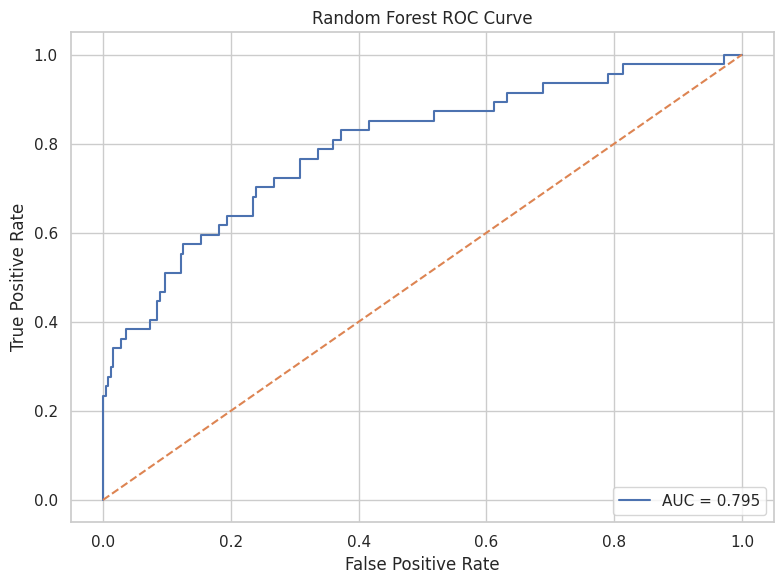

In [56]:
# Random Forest ROC Curve

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"AUC = {rf_auc:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

XGBoost
Validation Accuracy: 0.8597 ± 0.0025
Validation AUC     : 0.7602 ± 0.0374
Test Accuracy      : 0.8741
Test AUC           : 0.7865

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.75      0.32      0.45        47

    accuracy                           0.87       294
   macro avg       0.82      0.65      0.69       294
weighted avg       0.86      0.87      0.85       294



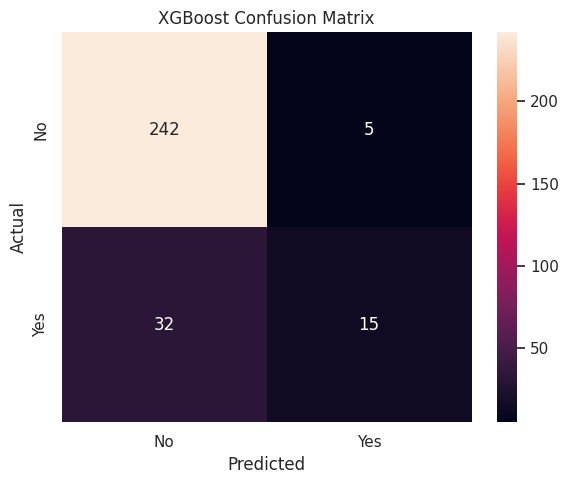

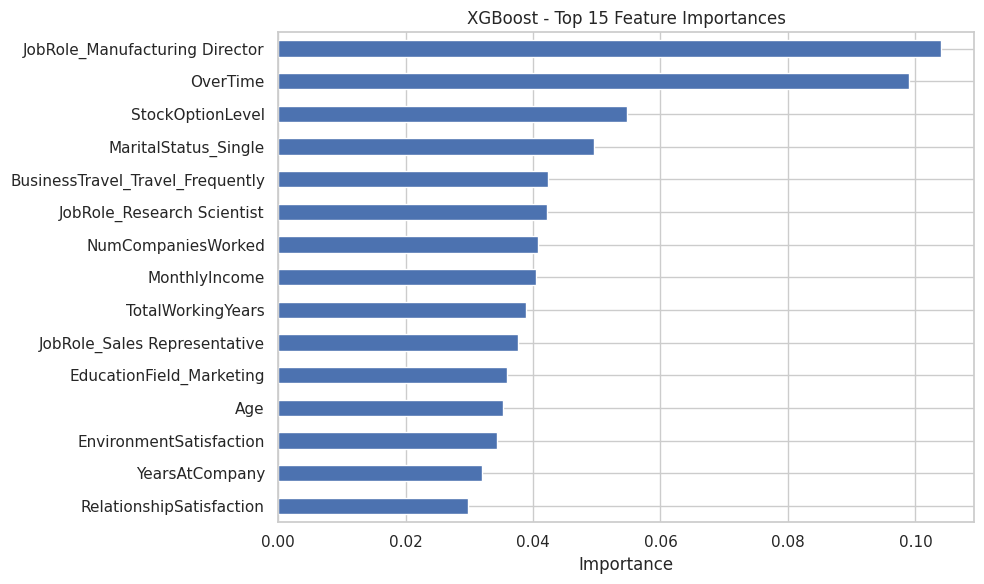

/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Run ID: c59a39c7fcd74c928d99f6547120bbc9
Logged Model ID: m-2f96d613ff7c44a5ba2a0061e222dee8
🏃 View run XGBoost_Advanced at: http://127.0.0.1:5001/#/experiments/1/runs/c59a39c7fcd74c928d99f6547120bbc9
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


In [58]:
# ============================================================
# MODEL 3: XGBOOST
# ============================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=50,
    eval_metric="auc"
)

with mlflow.start_run(run_name="XGBoost_Advanced") as run:

    # -------------------------
    # Validation
    # -------------------------
    cv_results = cross_validate(
        xgb_model,
        X_train,
        y_train,
        cv=CV,
        scoring=["accuracy", "roc_auc", "precision", "recall", "f1"],
        n_jobs=-1
    )

    xgb_val_accuracy_mean = cv_results["test_accuracy"].mean()
    xgb_val_accuracy_std = cv_results["test_accuracy"].std()
    xgb_val_auc_mean = cv_results["test_roc_auc"].mean()
    xgb_val_auc_std = cv_results["test_roc_auc"].std()

    # -------------------------
    # Train final model
    # -------------------------
    xgb_model.fit(X_train, y_train)

    y_pred3 = xgb_model.predict(X_test)
    y_prob3 = xgb_model.predict_proba(X_test)[:, 1]

    xgb_accuracy = accuracy_score(y_test, y_pred3)
    xgb_precision = precision_score(y_test, y_pred3, zero_division=0)
    xgb_recall = recall_score(y_test, y_pred3, zero_division=0)
    xgb_f1 = f1_score(y_test, y_pred3, zero_division=0)
    xgb_auc = roc_auc_score(y_test, y_prob3)

    print("XGBoost")
    print("Validation Accuracy:", f"{xgb_val_accuracy_mean:.4f} ± {xgb_val_accuracy_std:.4f}")
    print("Validation AUC     :", f"{xgb_val_auc_mean:.4f} ± {xgb_val_auc_std:.4f}")
    print("Test Accuracy      :", f"{xgb_accuracy:.4f}")
    print("Test AUC           :", f"{xgb_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred3, zero_division=0))

    # -------------------------
    # MLflow parameters/metrics
    # -------------------------
    mlflow.log_param("model_type", "XGBClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("random_state", 50)
    mlflow.log_param("eval_metric", "auc")
    mlflow.log_param("validation_folds", 5)

    mlflow.log_metric("validation_accuracy_mean", xgb_val_accuracy_mean)
    mlflow.log_metric("validation_accuracy_std", xgb_val_accuracy_std)
    mlflow.log_metric("validation_auc_mean", xgb_val_auc_mean)
    mlflow.log_metric("validation_auc_std", xgb_val_auc_std)

    mlflow.log_metric("accuracy", xgb_accuracy)
    mlflow.log_metric("precision", xgb_precision)
    mlflow.log_metric("recall", xgb_recall)
    mlflow.log_metric("f1_score", xgb_f1)
    mlflow.log_metric("auc", xgb_auc)

    # -------------------------
    # ROC
    # -------------------------
    xgb_fpr, xgb_tpr, xgb_thresholds = roc_curve(y_test, y_prob3)

    # -------------------------
    # Confusion matrix
    # -------------------------
    xgb_cm = confusion_matrix(y_test, y_pred3)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        xgb_cm,
        annot=True,
        fmt="d",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("XGBoost Confusion Matrix")
    plt.tight_layout()

    xgb_cm_path = PLOTS_DIR / "xgboost_confusion_matrix.png"
    plt.savefig(xgb_cm_path, dpi=150, bbox_inches="tight")
    plt.show()
    mlflow.log_artifact(str(xgb_cm_path), artifact_path="visualizations")

    # -------------------------
    # Feature importance
    # -------------------------
    xgb_importance = (
        pd.Series(xgb_model.feature_importances_, index=X_train.columns)
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10, 6))
    xgb_importance.sort_values().plot(kind="barh")
    plt.title("XGBoost - Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()

    xgb_fi_path = PLOTS_DIR / "xgboost_feature_importance.png"
    plt.savefig(xgb_fi_path, dpi=150, bbox_inches="tight")
    plt.show()
    mlflow.log_artifact(str(xgb_fi_path), artifact_path="visualizations")

    # -------------------------
    # Model signature + input example
    # -------------------------
    # -------------------------
    # Model signature + input example
    # -------------------------
    signature = infer_signature(
        X_train.head(5),
        xgb_model.predict(X_train.head(5))
    )

    model_info_xgb = mlflow.sklearn.log_model(
        xgb_model,
        name="XGBoost_model",
        signature=signature,
        input_example=X_train.head(5),
        skops_trusted_types=[
            "xgboost.core.Booster",
            "xgboost.sklearn.XGBClassifier"
        ]
    )

    print("Run ID:", run.info.run_id)
    print("Logged Model ID:", model_info_xgb.model_id)

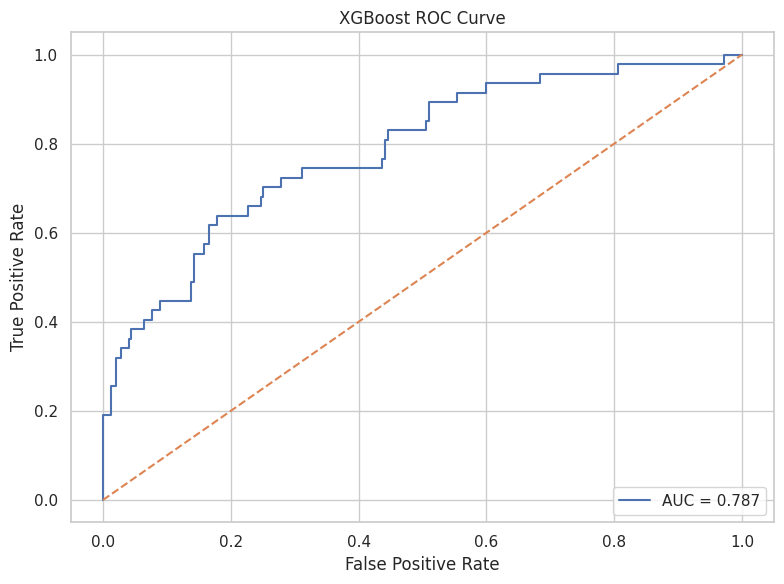

In [59]:
# XGBoost ROC Curve

plt.figure(figsize=(8, 6))

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"AUC = {xgb_auc:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Model Comparison, Validation and Final Model Selection

The three models are compared using:
- 5-fold stratified cross-validation on the training data (validation)
- Independent test-set accuracy/AUC/precision/recall/F1
- ROC curves and confusion matrices

The model with the highest **test accuracy** is selected for Model Registry. The validation metrics are retained in MLflow for reproducibility.

                 Model  Validation Accuracy Mean  Validation Accuracy Std  \
0  Logistic Regression                    0.8657                   0.0127   
1        Random Forest                    0.8529                   0.0084   
2              XGBoost                    0.8597                   0.0025   

   Validation AUC Mean  Test Accuracy  Test Precision  Test Recall  Test F1  \
0               0.8067         0.8673            0.70       0.2979   0.4179   
1               0.7678         0.8707            1.00       0.1915   0.3214   
2               0.7602         0.8741            0.75       0.3191   0.4478   

   Test AUC  
0    0.8072  
1    0.7947  
2    0.7865  


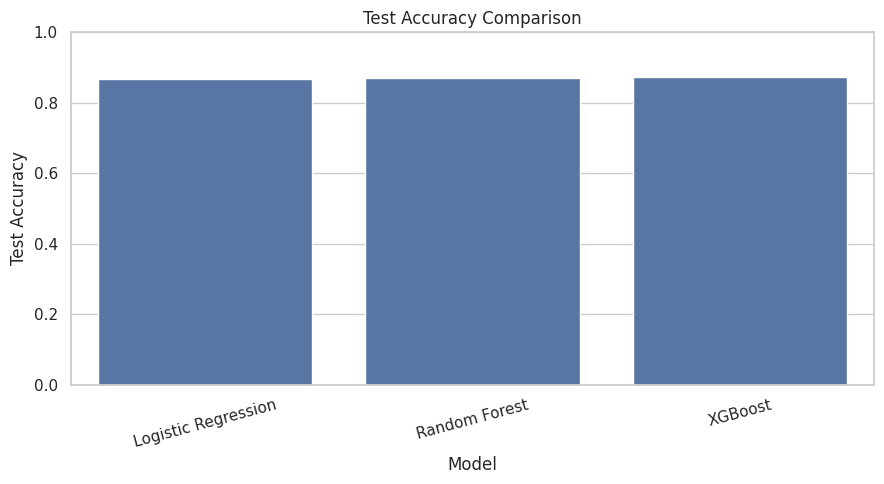

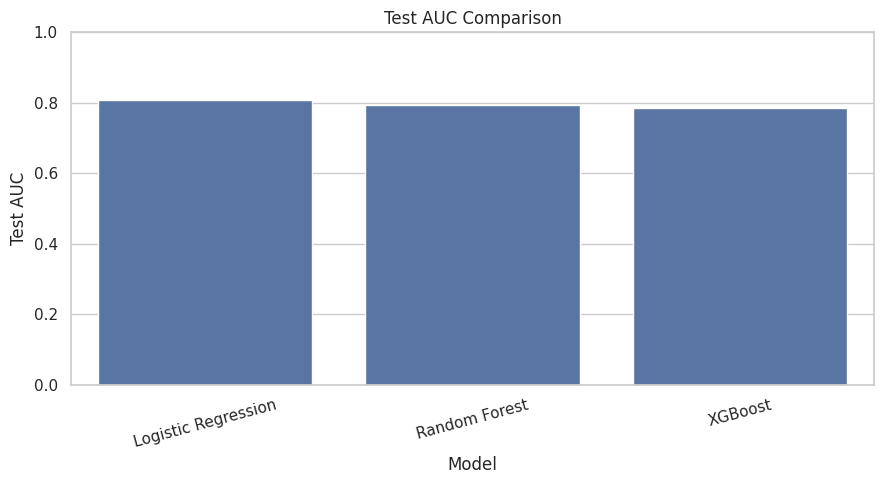

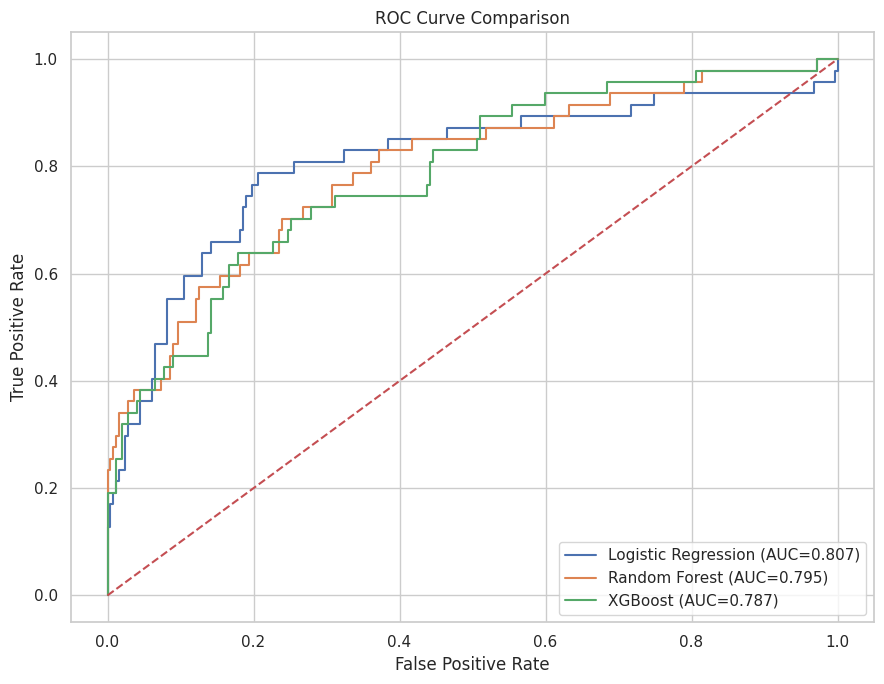


Best model by test accuracy:
XGBoost


In [60]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Validation Accuracy Mean": [
        val_accuracy_mean,
        rf_val_accuracy_mean,
        xgb_val_accuracy_mean
    ],
    "Validation Accuracy Std": [
        val_accuracy_std,
        rf_val_accuracy_std,
        xgb_val_accuracy_std
    ],
    "Validation AUC Mean": [
        val_auc_mean,
        rf_val_auc_mean,
        xgb_val_auc_mean
    ],
    "Test Accuracy": [
        test_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Test Precision": [
        test_precision,
        rf_precision,
        xgb_precision
    ],
    "Test Recall": [
        test_recall,
        rf_recall,
        xgb_recall
    ],
    "Test F1": [
        test_f1,
        rf_f1,
        xgb_f1
    ],
    "Test AUC": [
        test_auc,
        rf_auc,
        xgb_auc
    ]
})

print(results.round(4))

# -------------------------
# Accuracy comparison
# -------------------------
plt.figure(figsize=(9, 5))
sns.barplot(
    data=results,
    x="Model",
    y="Test Accuracy"
)
plt.ylim(0, 1)
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# -------------------------
# AUC comparison
# -------------------------
plt.figure(figsize=(9, 5))
sns.barplot(
    data=results,
    x="Model",
    y="Test AUC"
)
plt.ylim(0, 1)
plt.title("Test AUC Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# -------------------------
# Combined ROC comparison
# -------------------------
plt.figure(figsize=(9, 7))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression (AUC={test_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={rf_auc:.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC={xgb_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# -------------------------
# Save comparison results
# -------------------------
comparison_path = PLOTS_DIR / "model_comparison.csv"
results.to_csv(comparison_path, index=False)

print("\nBest model by test accuracy:")
best_model_name = results.loc[
    results["Test Accuracy"].idxmax(),
    "Model"
]
print(best_model_name)

In [61]:
# Log the overall comparison as a dedicated MLflow run.
with mlflow.start_run(run_name="Model_Comparison") as comparison_run:

    for _, row in results.iterrows():
        safe_name = (
            row["Model"]
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        mlflow.log_metric(
            f"{safe_name}_test_accuracy",
            float(row["Test Accuracy"])
        )
        mlflow.log_metric(
            f"{safe_name}_test_auc",
            float(row["Test AUC"])
        )
        mlflow.log_metric(
            f"{safe_name}_validation_accuracy_mean",
            float(row["Validation Accuracy Mean"])
        )

    mlflow.log_artifact(
        str(comparison_path),
        artifact_path="model_comparison"
    )

    mlflow.set_tag("selection_metric", "test_accuracy")
    mlflow.set_tag("best_model", best_model_name)

print("Model comparison logged to MLflow.")

🏃 View run Model_Comparison at: http://127.0.0.1:5001/#/experiments/1/runs/2841f06fe23a4cdb91083a7bcce25e56
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
Model comparison logged to MLflow.


# MLflow

In [62]:
# Process cleanup is handled automatically by the MLflow setup cell above.
# This cell is intentionally kept from the original notebook for continuity.
print("MLflow process cleanup is already handled.")

MLflow process cleanup is already handled.


In [63]:
# The original experimental MLflow snippet is replaced by the explicit
# three-model logging and registry workflow above.
print("Legacy MLflow example retained as a note; no action required.")

Legacy MLflow example retained as a note; no action required.


In [64]:
# ============================================================
# MLFLOW MODEL REGISTRY - MLflow 3 SAFE WORKFLOW
# ============================================================

import mlflow
from mlflow.tracking import MlflowClient
import pandas as pd

# Always communicate through the MLflow tracking server.
mlflow.set_tracking_uri(MLFLOW_LOCAL_URL)

client = MlflowClient()

print("Tracking URI:", mlflow.get_tracking_uri())

# ------------------------------------------------------------
# 1. Get experiment
# ------------------------------------------------------------
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    raise ValueError(
        f"Experiment '{EXPERIMENT_NAME}' was not found."
    )

experiment_id = experiment.experiment_id

print("Experiment ID:", experiment_id)

# ------------------------------------------------------------
# 2. Find the best model using test accuracy
# ------------------------------------------------------------
runs_df = mlflow.search_runs(
    experiment_ids=[experiment_id]
)

accuracy_col = "metrics.accuracy"

if accuracy_col not in runs_df.columns:
    raise ValueError(
        f"'{accuracy_col}' was not found in MLflow runs."
    )

runs_df[accuracy_col] = pd.to_numeric(
    runs_df[accuracy_col],
    errors="coerce"
)

candidate_runs = runs_df.dropna(
    subset=[accuracy_col]
).copy()

# Exclude the comparison run because it contains comparison metrics,
# not a single model accuracy metric.
candidate_runs = candidate_runs[
    candidate_runs["tags.mlflow.runName"] != "Model_Comparison"
].copy()

if candidate_runs.empty:
    raise ValueError("No valid model runs with accuracy were found.")

candidate_runs = candidate_runs.sort_values(
    by=accuracy_col,
    ascending=False
)

best_run = candidate_runs.iloc[0]

best_run_id = best_run["run_id"]
best_run_name = best_run["tags.mlflow.runName"]
best_score = float(best_run[accuracy_col])

print("\n" + "=" * 70)
print("BEST MODEL RUN")
print("=" * 70)
print("Run Name :", best_run_name)
print("Run ID   :", best_run_id)
print("Accuracy :", f"{best_score:.4f}")

# ------------------------------------------------------------
# 3. Find the MLflow 3 Logged Model for this run
# ------------------------------------------------------------
logged_models = mlflow.search_logged_models(
    experiment_ids=[experiment_id],
    filter_string=f"source_run_id = '{best_run_id}'",
    output_format="list"
)

if not logged_models:
    raise ValueError(
        "No Logged Model was found for the winning run. "
        "Make sure mlflow.sklearn.log_model() completed successfully."
    )

# Prefer READY models.
ready_models = [
    m for m in logged_models
    if str(m.status).upper().endswith("READY")
]

selected_logged_model = (
    ready_models[0]
    if ready_models
    else logged_models[0]
)

model_id = selected_logged_model.model_id
logged_model_name = selected_logged_model.name

print("\n" + "=" * 70)
print("LOGGED MODEL")
print("=" * 70)
print("Logged Model Name:", logged_model_name)
print("Model ID         :", model_id)
print("Status            :", selected_logged_model.status)

# ------------------------------------------------------------
# 4. MLflow 3 model-id URI
# ------------------------------------------------------------
model_uri = f"models:/{model_id}"

print("Model URI:", model_uri)

# ------------------------------------------------------------
# 5. Register model
# ------------------------------------------------------------
registered_model_name = "Best_Attrition_Prediction_Model"

model_details = mlflow.register_model(
    model_uri=model_uri,
    name=registered_model_name
)

print("\n" + "=" * 70)
print("MODEL REGISTRATION SUCCESSFUL")
print("=" * 70)
print("Registered Model:", model_details.name)
print("Version         :", model_details.version)
print("Best Accuracy   :", f"{best_score:.4f}")

# ------------------------------------------------------------
# 6. Add useful version tags
# ------------------------------------------------------------
client.set_model_version_tag(
    name=registered_model_name,
    version=model_details.version,
    key="model_type",
    value=best_model_name
)

client.set_model_version_tag(
    name=registered_model_name,
    version=model_details.version,
    key="test_accuracy",
    value=f"{best_score:.6f}"
)

client.set_model_version_tag(
    name=registered_model_name,
    version=model_details.version,
    key="source_run_id",
    value=best_run_id
)

# ------------------------------------------------------------
# 7. Set 'champion' alias to the newly registered best model
# ------------------------------------------------------------
try:
    client.set_registered_model_alias(
        registered_model_name,
        "champion",
        model_details.version
    )
    print(
        f"Alias 'champion' -> version {model_details.version}"
    )
except Exception as alias_error:
    print("Alias could not be set:", alias_error)

# ------------------------------------------------------------
# 8. Verify the registry
# ------------------------------------------------------------
registered = client.get_registered_model(
    registered_model_name
)

print("\nRegistered model:", registered.name)

for version in client.search_model_versions(
    f"name = '{registered_model_name}'"
):
    print(
        f"Version {version.version} | "
        f"Status={version.status} | "
        f"Run={version.run_id}"
    )

Tracking URI: http://127.0.0.1:5001
Experiment ID: 1

BEST MODEL RUN
Run Name : XGBoost_Advanced
Run ID   : c59a39c7fcd74c928d99f6547120bbc9
Accuracy : 0.8741

LOGGED MODEL
Logged Model Name: XGBoost_model
Model ID         : m-2f96d613ff7c44a5ba2a0061e222dee8
Status            : READY
Model URI: models:/m-2f96d613ff7c44a5ba2a0061e222dee8


Successfully registered model 'Best_Attrition_Prediction_Model'.
2026/08/07 22:55:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Best_Attrition_Prediction_Model, version 1
Created version '1' of model 'Best_Attrition_Prediction_Model'.



MODEL REGISTRATION SUCCESSFUL
Registered Model: Best_Attrition_Prediction_Model
Version         : 1
Best Accuracy   : 0.8741
Alias 'champion' -> version 1

Registered model: Best_Attrition_Prediction_Model
Version 1 | Status=READY | Run=c59a39c7fcd74c928d99f6547120bbc9


In [65]:
# ============================================================
# FINAL MODEL REGISTRY VERIFICATION / LOAD TEST
# ============================================================

mlflow.set_tracking_uri(MLFLOW_LOCAL_URL)

client = MlflowClient()

registered_model_name = "Best_Attrition_Prediction_Model"

# Get champion alias if available.
try:
    champion = client.get_model_version_by_alias(
        registered_model_name,
        "champion"
    )

    champion_uri = f"models:/{registered_model_name}@champion"

    print("Champion model version:", champion.version)
    print("Champion model URI:", champion_uri)

    loaded_model = mlflow.sklearn.load_model(champion_uri)

    sample_predictions = loaded_model.predict(
        X_test.head(10)
    )

    print("Sample predictions:", sample_predictions)

except Exception as e:
    print("Champion alias verification was not available:", e)

# Ensure no active run remains open.
if mlflow.active_run() is not None:
    mlflow.end_run()

print("\nMLflow workflow completed successfully.")
print("Dashboard URL:", MLFLOW_PUBLIC_URL)

Champion model version: 1
Champion model URI: models:/Best_Attrition_Prediction_Model@champion
Sample predictions: [0 0 0 0 0 1 0 0 0 0]

MLflow workflow completed successfully.
Dashboard URL: https://erratic-graceless-regalia.ngrok-free.dev


## MLflow Dashboard

After running the MLflow setup cells, open the printed:

**MLflow Dashboard URL**

It will look like:

`https://<random-name>.ngrok-free.dev`

Do not use `http://127.0.0.1:5001` from your desktop browser; that address exists inside the Colab runtime.

### MLflow objects created by this notebook

- Experiment: `employee_attrition`
- Runs: Logistic Regression, Random Forest, XGBoost, Model Comparison
- Logged Models: one for each trained model
- Metrics: validation accuracy/AUC plus test accuracy/precision/recall/F1/AUC
- Artifacts: ROC curves, confusion matrices, feature-importance plots, model comparison CSV
- Registered Model: `Best_Attrition_Prediction_Model`
- Alias: `champion` for the selected best model version